# Support Vector Machine Analysis for British Airways Reviews Dataset

## Project Overview
This notebook implements a comprehensive Support Vector Machine (SVM) analysis on British Airways customer reviews. 

### Objectives:
1. **Data Loading & Exploration**: Load and understand the dataset structure
2. **Data Cleaning**: Handle missing values, duplicates, and data quality issues
3. **Text Preprocessing**: Clean and prepare textual data for machine learning
4. **Feature Engineering**: Convert text reviews into numerical features
5. **SVM Implementation**: Build and optimize SVM classifier for sentiment prediction
6. **Model Evaluation**: Assess model performance with various metrics

### Dataset Information:
- **Source**: British Airways customer reviews
- **Target Variable**: Overall Rating (to be converted to sentiment categories)
- **Features**: Review text, traveller type, seat type, route, and service ratings

In [11]:
# Core Data Analysis Libraries
import pandas as pd                          # Data manipulation and analysis
import numpy as np                           # Numerical computing
import matplotlib.pyplot as plt              # Data visualization
import seaborn as sns                        # Statistical data visualization
import warnings                              # Handle warnings
warnings.filterwarnings('ignore')           # Suppress warnings for cleaner output

# Natural Language Processing Libraries
import nltk                                  # Natural language toolkit
import re                                    # Regular expressions for text processing
from nltk.corpus import stopwords           # Common words to remove
from nltk.tokenize import word_tokenize      # Text tokenization
from nltk.stem import PorterStemmer          # Word stemming
from textblob import TextBlob                # Text processing and sentiment analysis
from wordcloud import WordCloud             # Word cloud visualization

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC                  # Support Vector Classifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

## 1. Data Loading and Initial Exploration

Let's start by loading the British Airways reviews dataset and understanding its structure, dimensions, and basic characteristics.

In [12]:
# ====================================================================
# DATA LOADING AND INITIAL EXPLORATION
# ====================================================================

def load_and_explore_data(file_path):
    """
    Load the dataset and provide comprehensive initial exploration.
    
    Args:
        file_path (str): Path to the CSV file
    
    Returns:
        pd.DataFrame: Loaded dataset
    """
    # Load the dataset
    df = pd.read_csv(file_path)
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print("-" * 60)
    
    # Basic information about the dataset
    print("DATASET OVERVIEW:")
    print(f"   • Total Reviews: {df.shape[0]:,}")
    print(f"   • Total Features: {df.shape[1]}")
    print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("-" * 60)
    
    # Column information
    print("COLUMN INFORMATION:")
    for i, col in enumerate(df.columns, 1):
        print(f"   {i:2d}. {col}")
    print("-" * 60)
    
    # Data types
    print("DATA TYPES:")
    print(df.dtypes.value_counts())
    print("-" * 60)
    
    return df

# Load the dataset
ba_reviews = load_and_explore_data('BA_AirlineReviews.csv')

Dataset Shape: 3,701 rows × 20 columns
------------------------------------------------------------
DATASET OVERVIEW:
   • Total Reviews: 3,701
   • Total Features: 20
   • Memory Usage: 5.86 MB
------------------------------------------------------------
COLUMN INFORMATION:
    1. Unnamed: 0
    2. OverallRating
    3. ReviewHeader
    4. Name
    5. Datetime
    6. VerifiedReview
    7. ReviewBody
    8. TypeOfTraveller
    9. SeatType
   10. Route
   11. DateFlown
   12. SeatComfort
   13. CabinStaffService
   14. GroundService
   15. ValueForMoney
   16. Recommended
   17. Aircraft
   18. Food&Beverages
   19. InflightEntertainment
   20. Wifi&Connectivity
------------------------------------------------------------
DATA TYPES:
object     10
float64     8
int64       1
bool        1
Name: count, dtype: int64
------------------------------------------------------------


In [13]:
# ====================================================================
# DETAILED DATA EXPLORATION
# ====================================================================

def detailed_data_exploration(df):
    """
    Perform comprehensive data exploration including missing values, 
    unique values, and statistical summaries.
    
    Args:
        df (pd.DataFrame): The dataset to explore
    """
    print("DETAILED DATA EXPLORATION")
    print("=" * 80)
    
    # Display first few rows
    print("FIRST 5 ROWS:")
    print(df.head())
    print("-" * 80)
    
    # Missing values analysis
    print("MISSING VALUES ANALYSIS:")
    missing_stats = df.isnull().sum()
    missing_percent = (missing_stats / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing_stats,
        'Missing Percentage': missing_percent.round(2)
    }).sort_values('Missing Count', ascending=False)
    
    print(missing_df[missing_df['Missing Count'] > 0])
    print("-" * 80)
    
    # Target variable (OverallRating) distribution
    print("TARGET VARIABLE ANALYSIS (Overall Rating):")
    rating_counts = df['OverallRating'].value_counts().sort_index()
    print("Rating Distribution:")
    for rating, count in rating_counts.items():
        percentage = (count / len(df)) * 100
        print(f"   Rating {rating}: {count:4d} reviews ({percentage:5.1f}%)")
    print("-" * 80)
    
    # Key text features analysis
    print("TEXT FEATURES ANALYSIS:")
    text_features = ['ReviewHeader', 'ReviewBody']
    for feature in text_features:
        if feature in df.columns:
            non_null_count = df[feature].notna().sum()
            avg_length = df[feature].dropna().str.len().mean()
            print(f"   {feature}:")
            print(f"      • Non-null entries: {non_null_count:,}")
            print(f"      • Average length: {avg_length:.1f} characters")
    
    print("-" * 80)
    
    # Categorical features analysis
    print("CATEGORICAL FEATURES ANALYSIS:")
    categorical_cols = ['TypeOfTraveller', 'SeatType', 'Recommended', 'Aircraft']
    for col in categorical_cols:
        if col in df.columns:
            unique_count = df[col].nunique()
            print(f"   {col}: {unique_count} unique values")
            if unique_count <= 10:  # Show distribution for features with few categories
                print(f"      Distribution: {dict(df[col].value_counts().head())}")
    
    return missing_df

# Perform detailed exploration
missing_analysis = detailed_data_exploration(ba_reviews)

DETAILED DATA EXPLORATION
FIRST 5 ROWS:
   Unnamed: 0  OverallRating                              ReviewHeader  \
0           0            1.0    "Service level far worse then Ryanair"   
1           1            3.0  "do not upgrade members based on status"   
2           2            8.0             "Flight was smooth and quick"   
3           3            1.0             "Absolutely hopeless airline"   
4           4            1.0        "Customer Service is non existent"   

               Name            Datetime  VerifiedReview  \
0           L Keele  19th November 2023            True   
1      Austin Jones  19th November 2023            True   
2        M A Collie  16th November 2023           False   
3        Nigel Dean  16th November 2023            True   
4  Gaylynne Simpson  14th November 2023           False   

                                          ReviewBody TypeOfTraveller  \
0  4 Hours before takeoff we received a Mail stat...  Couple Leisure   
1  I recently ha

## 2. Data Cleaning and Preprocessing

Based on our exploration, we need to:
1. Handle missing values strategically
2. Create meaningful target labels for SVM classification
3. Clean and preprocess text data
4. Handle categorical variables appropriately

Let's implement a comprehensive data cleaning pipeline.

In [14]:
# ====================================================================
# DATA CLEANING AND PREPROCESSING FUNCTIONS
# ====================================================================

def create_sentiment_labels(df, rating_column='OverallRating'):
    """
    Convert numerical ratings to sentiment categories for classification.
    
    Args:
        df (pd.DataFrame): Dataset with ratings
        rating_column (str): Name of the rating column
    
    Returns:
        pd.DataFrame: Dataset with sentiment labels
    """
    print("Creating Sentiment Labels from Ratings...")
    
    # Create a copy to avoid modifying original data
    df_clean = df.copy()
    
    # Remove rows with missing ratings
    initial_count = len(df_clean)
    df_clean = df_clean.dropna(subset=[rating_column])
    removed_count = initial_count - len(df_clean)
    
    print(f"Removed {removed_count} rows with missing ratings")
    print(f"Remaining rows: {len(df_clean):,}")
    
    # Create sentiment categories based on rating scale (1-10)
    # Negative: 1-3, Neutral: 4-6, Positive: 7-10
    def rating_to_sentiment(rating):
        if pd.isna(rating):
            return None
        elif rating <= 3:
            return 'Negative'
        elif rating <= 6:
            return 'Neutral'
        else:
            return 'Positive'
    
    df_clean['Sentiment'] = df_clean[rating_column].apply(rating_to_sentiment)
    
    # Display sentiment distribution
    sentiment_dist = df_clean['Sentiment'].value_counts()
    print("Sentiment Distribution:")
    for sentiment, count in sentiment_dist.items():
        percentage = (count / len(df_clean)) * 100
        print(f"   • {sentiment}: {count:,} reviews ({percentage:.1f}%)")
    
    return df_clean

def clean_text_data(text):
    """
    Clean and preprocess text data for NLP analysis.
    
    Args:
        text (str): Raw text to clean
    
    Returns:
        str: Cleaned text
    """
    if pd.isna(text) or text == '':
        return ''
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove quotes and special characters from review headers
    text = re.sub(r'^["\']|["\']$', '', text)  # Remove leading/trailing quotes
    
    # Remove extra whitespace and newlines
    text = ' '.join(text.split())
    
    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^\w\s.,!?-]', ' ', text)
    
    # Remove extra spaces
    text = ' '.join(text.split())
    
    return text.strip()

def comprehensive_data_cleaning(df):
    """
    Perform comprehensive data cleaning including missing values,
    text preprocessing, and feature engineering.
    
    Args:
        df (pd.DataFrame): Raw dataset
    
    Returns:
        pd.DataFrame: Cleaned dataset
    """
    print("COMPREHENSIVE DATA CLEANING")
    print("=" * 60)
    
    # Start with sentiment label creation
    df_clean = create_sentiment_labels(df)
    
    print("Cleaning Text Data...")
    
    # Clean text columns
    text_columns = ['ReviewHeader', 'ReviewBody']
    for col in text_columns:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].apply(clean_text_data)
            print(f"   • Cleaned {col}")
    
    # Combine review header and body for richer text features
    df_clean['CombinedReview'] = (
        df_clean['ReviewHeader'].fillna('') + ' ' + 
        df_clean['ReviewBody'].fillna('')
    ).str.strip()
    
    print("   • Created combined review text")
    
    # Fill missing categorical values with 'Unknown'
    categorical_columns = ['TypeOfTraveller', 'SeatType', 'Aircraft']
    for col in categorical_columns:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna('Unknown')
            print(f"   • Filled missing values in {col}")
    
    # Fill missing boolean/categorical values
    if 'Recommended' in df_clean.columns:
        df_clean['Recommended'] = df_clean['Recommended'].fillna('unknown')
    
    # Remove the unnecessary index column if it exists
    if 'Unnamed: 0' in df_clean.columns:
        df_clean = df_clean.drop('Unnamed: 0', axis=1)
        print("   • Removed unnecessary index column")
    
    print(f"Data cleaning completed!")
    print(f"   • Final dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
    
    return df_clean

# Apply comprehensive cleaning
ba_reviews_clean = comprehensive_data_cleaning(ba_reviews)

COMPREHENSIVE DATA CLEANING
Creating Sentiment Labels from Ratings...
Removed 5 rows with missing ratings
Remaining rows: 3,696
Sentiment Distribution:
   • Negative: 1,695 reviews (45.9%)
   • Positive: 1,323 reviews (35.8%)
   • Neutral: 678 reviews (18.3%)
Cleaning Text Data...
   • Cleaned ReviewHeader
   • Cleaned ReviewBody
   • Created combined review text
   • Filled missing values in TypeOfTraveller
   • Filled missing values in SeatType
   • Filled missing values in Aircraft
   • Removed unnecessary index column
Data cleaning completed!
   • Final dataset shape: 3,696 rows × 21 columns


In [16]:
# ====================================================================
# ADVANCED TEXT PREPROCESSING FOR NLP
# ====================================================================

class TextPreprocessor:
    """
    Advanced text preprocessing class for preparing review text for SVM.
    Implements comprehensive text cleaning, tokenization, and normalization.
    """
    
    def __init__(self):
        """Initialize the preprocessor with necessary components."""
        self.stop_words = set(stopwords.words('english'))
        self.stemmer = PorterStemmer()
        
        # Add domain-specific stop words
        self.stop_words.update(['flight', 'airline', 'british', 'airways', 'ba', 
                               'plane', 'aircraft', 'review', 'travel'])
        
        print("TextPreprocessor initialized with enhanced stop words")
    
    def preprocess_text(self, text):
        """
        Apply comprehensive text preprocessing pipeline.
        
        Args:
            text (str): Raw text to preprocess
        
        Returns:
            str: Processed text ready for vectorization
        """
        if pd.isna(text) or text == '':
            return ''
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove URLs and email addresses
        text = re.sub(r'http\\S+|www\\S+|@\\S+', '', text)
        
        # Remove numbers and special characters, keep only letters and spaces
        text = re.sub(r'[^a-zA-Z\\s]', ' ', text)
        
        # Tokenize the text
        tokens = word_tokenize(text)
        
        # Remove stop words and short tokens (less than 3 characters)
        tokens = [token for token in tokens 
                 if token not in self.stop_words and len(token) >= 3]
        
        # Apply stemming to reduce words to their root form
        tokens = [self.stemmer.stem(token) for token in tokens]
        
        # Join tokens back into text
        processed_text = ' '.join(tokens)
        
        return processed_text
    
    def get_text_statistics(self, texts):
        """
        Calculate comprehensive statistics for text data.
        
        Args:
            texts (pd.Series): Series of text data
        
        Returns:
            dict: Dictionary of text statistics
        """
        text_lengths = texts.str.len()
        word_counts = texts.str.split().str.len()
        
        stats = {
            'total_texts': len(texts),
            'avg_char_length': text_lengths.mean(),
            'avg_word_count': word_counts.mean(),
            'max_char_length': text_lengths.max(),
            'min_char_length': text_lengths.min(),
            'empty_texts': (texts == '').sum(),
            'unique_texts': texts.nunique()
        }
        
        return stats

def apply_advanced_text_preprocessing(df):
    """
    Apply advanced text preprocessing to the cleaned dataset.
    
    Args:
        df (pd.DataFrame): Cleaned dataset
    
    Returns:
        pd.DataFrame: Dataset with processed text features
    """
    print("ADVANCED TEXT PREPROCESSING")
    print("=" * 60)
    
    # Initialize preprocessor
    preprocessor = TextPreprocessor()
    
    # Create a copy to work with
    df_processed = df.copy()
    
    print("Processing Text Features...")
    
    # Apply preprocessing to combined review text
    print("Processing combined review text...")
    df_processed['ProcessedReview'] = df_processed['CombinedReview'].apply(
        preprocessor.preprocess_text
    )
    
    # Get statistics for original and processed text
    print("TEXT STATISTICS:")
    
    original_stats = preprocessor.get_text_statistics(df_processed['CombinedReview'])
    processed_stats = preprocessor.get_text_statistics(df_processed['ProcessedReview'])
    
    print("Original Text:")
    print(f"   • Average character length: {original_stats['avg_char_length']:.1f}")
    print(f"   • Average word count: {original_stats['avg_word_count']:.1f}")
    print(f"   • Unique texts: {original_stats['unique_texts']:,}")
    
    print("Processed Text:")
    print(f"   • Average character length: {processed_stats['avg_char_length']:.1f}")
    print(f"   • Average word count: {processed_stats['avg_word_count']:.1f}")
    print(f"   • Empty texts: {processed_stats['empty_texts']}")
    
    # Remove rows with empty processed text
    initial_count = len(df_processed)
    df_processed = df_processed[df_processed['ProcessedReview'] != '']
    removed_empty = initial_count - len(df_processed)
    
    if removed_empty > 0:
        print(f" Removed {removed_empty} rows with empty processed text")
    
    print(f"Text preprocessing completed!")
    print(f"   • Final dataset shape: {df_processed.shape[0]:,} rows × {df_processed.shape[1]} columns")
    
    return df_processed

# Apply advanced text preprocessing
ba_reviews_processed = apply_advanced_text_preprocessing(ba_reviews_clean)

ADVANCED TEXT PREPROCESSING
TextPreprocessor initialized with enhanced stop words
Processing Text Features...
Processing combined review text...
TEXT STATISTICS:
Original Text:
   • Average character length: 909.1
   • Average word count: 166.6
   • Unique texts: 3,687
Processed Text:
   • Average character length: 477.2
   • Average word count: 78.1
   • Empty texts: 0
Text preprocessing completed!
   • Final dataset shape: 3,696 rows × 22 columns


In [17]:
# ====================================================================
# FIXED PRE-SVM TEXT PROCESSING
# ====================================================================

def analyze_text_issue(df):
    """
    Analyze the text processing issue to understand why vocabulary is empty.
    """
    print("🔍 ANALYZING TEXT PROCESSING ISSUE")
    print("=" * 60)
    
    # Check original and processed text
    sample_size = 5
    print("📝 Sample original vs processed text:")
    
    for i in range(sample_size):
        original = df['CombinedReview'].iloc[i][:100]
        processed = df['ProcessedReview'].iloc[i][:100]
        
        print(f"\nSample {i+1}:")
        print(f"  Original: '{original}...'")
        print(f"  Processed: '{processed}...'")
    
    # Test simple regex patterns
    sample_text = df['ProcessedReview'].iloc[0]
    print(f"\n🧪 Testing regex patterns on: '{sample_text[:50]}...'")
    
    # Test different patterns
    patterns = [
        r'\b\w+\b',           # Simple word pattern
        r'\b[a-zA-Z]+\b',     # Only letters
        r'\b[a-zA-Z]{2,}\b',  # Letters, 2+ chars
        r'[a-zA-Z]+'          # Any letters
    ]
    
    for pattern in patterns:
        matches = re.findall(pattern, sample_text)
        print(f"  Pattern '{pattern}': {len(matches)} matches")
        if matches:
            print(f"    First few: {matches[:5]}")

# Run the analysis
analyze_text_issue(ba_reviews_processed)

print("\n" + "="*60)

def create_working_text_features(df):
    """
    Create text features that actually work for SVM by using the original text
    with minimal but effective preprocessing.
    """
    print("🚀 CREATING WORKING TEXT FEATURES FOR SVM")
    print("=" * 60)
    
    # Use the original combined review text with basic cleaning
    print("📝 Using original combined text with basic cleaning...")
    
    # Simple but effective text cleaning
    def simple_clean_text(text):
        if pd.isna(text):
            return ""
        # Convert to string and basic cleaning
        text = str(text)
        # Remove extra whitespace
        text = ' '.join(text.split())
        return text
    
    # Apply simple cleaning to combined review
    df_working = df.copy()
    df_working['CleanText'] = df_working['CombinedReview'].apply(simple_clean_text)
    
    # Check the results
    print(f"✅ Clean text created!")
    print(f"   • Total texts: {len(df_working):,}")
    print(f"   • Non-empty texts: {(df_working['CleanText'] != '').sum():,}")
    print(f"   • Average length: {df_working['CleanText'].str.len().mean():.1f} chars")
    
    # Test TF-IDF with this cleaned text
    print("\n🧪 Testing TF-IDF with cleaned text...")
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    # Create a more permissive TF-IDF vectorizer
    test_vectorizer = TfidfVectorizer(
        max_features=1000,
        min_df=1,                    # Very permissive
        max_df=0.99,
        stop_words='english',
        lowercase=True,
        token_pattern=r'\b[a-zA-Z]{2,}\b',  # Simple pattern: letters only, 2+ chars
        ngram_range=(1, 1)           # Only unigrams for now
    )
    
    # Test on a small sample first
    sample_texts = df_working['CleanText'].head(100).tolist()
    
    try:
        test_features = test_vectorizer.fit_transform(sample_texts)
        print(f"   ✅ SUCCESS! Test features shape: {test_features.shape}")
        print(f"   • Vocabulary size: {len(test_vectorizer.vocabulary_)}")
        print(f"   • Sample words: {list(test_vectorizer.get_feature_names_out())[:10]}")
        
        return df_working, test_vectorizer, True
        
    except Exception as e:
        print(f"   ❌ Still failed: {e}")
        return df_working, None, False

# Try the working approach
df_working, test_vectorizer, success = create_working_text_features(ba_reviews_processed)

🔍 ANALYZING TEXT PROCESSING ISSUE
📝 Sample original vs processed text:

Sample 1:
  Original: 'service level far worse then ryanair 4 hours before takeoff we received a mail stating a cryptic mes...'
  Processed: 'servic level far wors ryanair hour takeoff receiv mail state cryptic messag disrupt expect limit man...'

Sample 2:
  Original: 'do not upgrade members based on status i recently had a delay on british airways from bru to lhr tha...'
  Processed: 'upgrad member base statu recent delay bru lhr due staff shortag announc hour hold delay would board ...'

Sample 3:
  Original: 'flight was smooth and quick boarded on time, but it took ages to get to the runway due to congestion...'
  Processed: 'smooth quick board time took age get runway due congest smooth quick snack drink good short land ten...'

Sample 4:
  Original: 'absolutely hopeless airline 5 days before the flight, we were advised by ba that it had been cancell...'
  Processed: 'absolut hopeless day advis cancel ask rebo

In [18]:
# ====================================================================
# COMPLETE SVM FEATURE PREPARATION AND IMPLEMENTATION
# ====================================================================

def prepare_svm_features_complete(df):
    """
    Complete feature preparation pipeline for SVM classification.
    """
    print("🔧 COMPLETE SVM FEATURE PREPARATION")
    print("=" * 60)
    
    # Prepare target variable
    print("🎯 Preparing target variable...")
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['Sentiment'])
    
    print("Target encoding:")
    for i, sentiment in enumerate(label_encoder.classes_):
        count = (y == i).sum()
        print(f"   • {sentiment}: {i} ({count:,} samples)")
    
    # Split data
    print(f"\n📊 Splitting data...")
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        df, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"   • Training: {len(X_train_df):,} samples")
    print(f"   • Testing: {len(X_test_df):,} samples")
    
    # Create text features using the working approach
    print(f"\n📝 Creating TF-IDF text features...")
    
    tfidf_vectorizer = TfidfVectorizer(
        max_features=3000,
        min_df=2,
        max_df=0.95,
        stop_words='english',
        lowercase=True,
        token_pattern=r'\b[a-zA-Z]{2,}\b',
        ngram_range=(1, 2),  # Unigrams and bigrams
        sublinear_tf=True    # Use sublinear tf scaling
    )
    
    # Fit on training text and transform both sets
    X_train_text = tfidf_vectorizer.fit_transform(X_train_df['CleanText'])
    X_test_text = tfidf_vectorizer.transform(X_test_df['CleanText'])
    
    print(f"   ✅ Text features created!")
    print(f"   • Training text features: {X_train_text.shape}")
    print(f"   • Test text features: {X_test_text.shape}")
    print(f"   • Vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")
    
    # Encode categorical features
    print(f"\n🏷️ Encoding categorical features...")
    
    categorical_cols = ['TypeOfTraveller', 'SeatType', 'Recommended']
    categorical_encoders = {}
    X_train_cat = []
    X_test_cat = []
    
    for col in categorical_cols:
        # Fit encoder on training data
        categorical_encoders[col] = LabelEncoder()
        train_encoded = categorical_encoders[col].fit_transform(X_train_df[col].astype(str))
        
        # Transform test data, handling unseen categories
        test_col = X_test_df[col].astype(str)
        seen_categories = set(categorical_encoders[col].classes_)
        test_mapped = test_col.apply(lambda x: x if x in seen_categories else categorical_encoders[col].classes_[0])
        test_encoded = categorical_encoders[col].transform(test_mapped)
        
        X_train_cat.append(train_encoded.reshape(-1, 1))
        X_test_cat.append(test_encoded.reshape(-1, 1))
        
        print(f"   • {col}: {len(categorical_encoders[col].classes_)} categories")
    
    # Combine categorical features
    X_train_cat_combined = np.hstack(X_train_cat)
    X_test_cat_combined = np.hstack(X_test_cat)
    
    print(f"   • Total categorical features: {X_train_cat_combined.shape[1]}")
    
    # Combine text and categorical features
    print(f"\n🔗 Combining all features...")
    from scipy.sparse import hstack, csr_matrix
    
    X_train_final = hstack([X_train_text, csr_matrix(X_train_cat_combined)])
    X_test_final = hstack([X_test_text, csr_matrix(X_test_cat_combined)])
    
    print(f"   ✅ Final feature matrices created!")
    print(f"   • Training features: {X_train_final.shape}")
    print(f"   • Test features: {X_test_final.shape}")
    print(f"   • Feature sparsity: {(1 - X_train_final.nnz / X_train_final.size) * 100:.2f}%")
    
    return (X_train_final, X_test_final, y_train, y_test, 
            label_encoder, tfidf_vectorizer, categorical_encoders)

# Prepare features for SVM
(X_train, X_test, y_train, y_test, 
 label_encoder, tfidf_vectorizer, categorical_encoders) = prepare_svm_features_complete(df_working)

🔧 COMPLETE SVM FEATURE PREPARATION
🎯 Preparing target variable...
Target encoding:
   • Negative: 0 (1,695 samples)
   • Neutral: 1 (678 samples)
   • Positive: 2 (1,323 samples)

📊 Splitting data...
   • Training: 2,956 samples
   • Testing: 740 samples

📝 Creating TF-IDF text features...
   ✅ Text features created!
   • Training text features: (2956, 3000)
   • Test text features: (740, 3000)
   • Vocabulary size: 3,000

🏷️ Encoding categorical features...
   • TypeOfTraveller: 5 categories
   • SeatType: 5 categories
   • Recommended: 2 categories
   • Total categorical features: 3

🔗 Combining all features...
   ✅ Final feature matrices created!
   • Training features: (2956, 3003)
   • Test features: (740, 3003)
   • Feature sparsity: 0.00%


## 5. SVM Implementation and Optimization

Now we'll implement Support Vector Machine classifiers with different kernels and perform hyperparameter optimization to achieve the best performance for sentiment classification.

In [19]:
# ====================================================================
# COMPREHENSIVE SVM IMPLEMENTATION
# ====================================================================

class SVMClassifierSuite:
    """
    Comprehensive SVM classifier suite with multiple kernels,
    hyperparameter optimization, and detailed evaluation.
    """
    
    def __init__(self):
        """Initialize the SVM classifier suite."""
        self.models = {}
        self.best_model = None
        self.results = {}
        
        print("🤖 SVMClassifierSuite initialized")
        print("   Available kernels: Linear, RBF, Polynomial")
    
    def train_baseline_models(self, X_train, y_train):
        """
        Train baseline SVM models with different kernels.
        
        Args:
            X_train: Training features
            y_train: Training labels
        """
        print("🚀 TRAINING BASELINE SVM MODELS")
        print("=" * 60)
        
        # Define baseline configurations
        baseline_configs = {
            'Linear SVM': {
                'kernel': 'linear',
                'C': 1.0,
                'random_state': 42
            },
            'RBF SVM': {
                'kernel': 'rbf',
                'C': 1.0,
                'gamma': 'scale',
                'random_state': 42
            },
            'Polynomial SVM': {
                'kernel': 'poly',
                'C': 1.0,
                'degree': 3,
                'gamma': 'scale',
                'random_state': 42
            }
        }
        
        # Train each baseline model
        for name, config in baseline_configs.items():
            print(f"\n📚 Training {name}...")
            
            # Create and train model
            model = SVC(**config, probability=True)  # Enable probability for ROC curves
            
            # Time the training
            import time
            start_time = time.time()
            model.fit(X_train, y_train)
            train_time = time.time() - start_time
            
            # Store model and info
            self.models[name] = {
                'model': model,
                'config': config,
                'train_time': train_time
            }
            
            print(f"   ✅ {name} trained in {train_time:.2f} seconds")
            print(f"   • Support vectors: {model.n_support_}")
            print(f"   • Total support vectors: {sum(model.n_support_)}")
    
    def evaluate_models(self, X_test, y_test, label_encoder):
        """
        Evaluate all trained models on the test set.
        
        Args:
            X_test: Test features
            y_test: Test labels
            label_encoder: Encoder for converting labels back to text
        """
        print(f"\n📊 EVALUATING ALL MODELS")
        print("=" * 60)
        
        class_names = label_encoder.classes_
        
        for name, model_info in self.models.items():
            print(f"\n🔍 Evaluating {name}...")
            
            model = model_info['model']
            
            # Make predictions
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average='weighted')
            recall = recall_score(y_test, y_pred, average='weighted')
            f1 = f1_score(y_test, y_pred, average='weighted')
            
            # Store results
            self.results[name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba,
                'train_time': model_info['train_time']
            }
            
            print(f"   • Accuracy:  {accuracy:.4f}")
            print(f"   • Precision: {precision:.4f}")
            print(f"   • Recall:    {recall:.4f}")
            print(f"   • F1-Score:  {f1:.4f}")
            
            # Detailed classification report
            print(f"\\n   📋 Classification Report:")
            report = classification_report(y_test, y_pred, 
                                         target_names=class_names,
                                         output_dict=True)
            
            for class_name in class_names:
                class_metrics = report[class_name]
                print(f"      {class_name:>8}: P={class_metrics['precision']:.3f}, "
                      f"R={class_metrics['recall']:.3f}, F1={class_metrics['f1-score']:.3f}")
    
    def hyperparameter_optimization(self, X_train, y_train, X_val=None, y_val=None):
        """
        Perform hyperparameter optimization for the best performing baseline model.
        
        Args:
            X_train: Training features
            y_train: Training labels
            X_val: Validation features (optional)
            y_val: Validation labels (optional)
        """
        print(f"\\n⚡ HYPERPARAMETER OPTIMIZATION")
        print("=" * 60)
        
        # Find best baseline model
        best_baseline = max(self.results.keys(), 
                           key=lambda x: self.results[x]['f1_score'])
        
        print(f"🎯 Optimizing {best_baseline} (best baseline F1: {self.results[best_baseline]['f1_score']:.4f})")
        
        # Get the kernel type for optimization
        baseline_kernel = self.models[best_baseline]['config']['kernel']
        
        # Define parameter grids for different kernels
        if baseline_kernel == 'linear':
            param_grid = {
                'C': [0.1, 1.0, 10.0, 100.0],
                'class_weight': [None, 'balanced']
            }
        elif baseline_kernel == 'rbf':
            param_grid = {
                'C': [0.1, 1.0, 10.0, 100.0],
                'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
                'class_weight': [None, 'balanced']
            }
        else:  # polynomial
            param_grid = {
                'C': [0.1, 1.0, 10.0],
                'degree': [2, 3, 4],
                'gamma': ['scale', 'auto', 0.01, 0.1],
                'class_weight': [None, 'balanced']
            }
        
        # Create base model
        base_config = self.models[best_baseline]['config'].copy()
        base_model = SVC(kernel=baseline_kernel, random_state=42, probability=True)
        
        # Perform grid search with cross-validation
        print(f"🔍 Performing grid search with cross-validation...")
        print(f"   • Parameter combinations: {len(param_grid['C']) * len(param_grid.get('gamma', [1])) * len(param_grid.get('class_weight', [1]))}")
        
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=5,                    # 5-fold cross-validation
            scoring='f1_weighted',   # Use weighted F1-score
            n_jobs=-1,              # Use all available cores
            verbose=1               # Show progress
        )
        
        # Fit grid search
        grid_search.fit(X_train, y_train)
        
        # Store the best model
        self.best_model = grid_search.best_estimator_
        
        print(f"\\n✅ Hyperparameter optimization completed!")
        print(f"   • Best parameters: {grid_search.best_params_}")
        print(f"   • Best CV F1-score: {grid_search.best_score_:.4f}")
        print(f"   • Improvement: {grid_search.best_score_ - self.results[best_baseline]['f1_score']:.4f}")
        
        return grid_search
    
    def get_performance_summary(self):
        """
        Get a comprehensive performance summary of all models.
        
        Returns:
            pd.DataFrame: Summary of model performances
        """
        print(f"\\n📈 MODEL PERFORMANCE SUMMARY")
        print("=" * 60)
        
        summary_data = []
        for name, results in self.results.items():
            summary_data.append({
                'Model': name,
                'Accuracy': f"{results['accuracy']:.4f}",
                'Precision': f"{results['precision']:.4f}",
                'Recall': f"{results['recall']:.4f}",
                'F1-Score': f"{results['f1_score']:.4f}",
                'Training Time (s)': f"{results['train_time']:.2f}"
            })
        
        summary_df = pd.DataFrame(summary_data)
        
        # Sort by F1-score
        summary_df = summary_df.sort_values('F1-Score', ascending=False)
        
        print(summary_df.to_string(index=False))
        
        return summary_df

# Initialize and train SVM models
svm_suite = SVMClassifierSuite()
svm_suite.train_baseline_models(X_train, y_train)
svm_suite.evaluate_models(X_test, y_test, label_encoder)

🤖 SVMClassifierSuite initialized
   Available kernels: Linear, RBF, Polynomial
🚀 TRAINING BASELINE SVM MODELS

📚 Training Linear SVM...
   ✅ Linear SVM trained in 18.79 seconds
   • Support vectors: [748 541 502]
   • Total support vectors: 1791

📚 Training RBF SVM...
   ✅ RBF SVM trained in 22.12 seconds
   • Support vectors: [886 542 653]
   • Total support vectors: 2081

📚 Training Polynomial SVM...
   ✅ Polynomial SVM trained in 23.61 seconds
   • Support vectors: [969 541 608]
   • Total support vectors: 2118

📊 EVALUATING ALL MODELS

🔍 Evaluating Linear SVM...
   • Accuracy:  0.7932
   • Precision: 0.7322
   • Recall:    0.7932
   • F1-Score:  0.7399
\n   📋 Classification Report:
      Negative: P=0.780, R=0.953, F1=0.858
       Neutral: P=0.379, R=0.081, F1=0.133
      Positive: P=0.852, R=0.955, F1=0.900

🔍 Evaluating RBF SVM...
   • Accuracy:  0.8000
   • Precision: 0.6554
   • Recall:    0.8000
   • F1-Score:  0.7197
\n   📋 Classification Report:
      Negative: P=0.764, R=0.

In [20]:
# ====================================================================
# HYPERPARAMETER OPTIMIZATION AND FINAL EVALUATION
# ====================================================================

# Perform hyperparameter optimization on the best model
print("\\nStarting hyperparameter optimization...")
grid_search_result = svm_suite.hyperparameter_optimization(X_train, y_train)

# Evaluate the optimized model
print("\\n🏆 EVALUATING OPTIMIZED MODEL")
print("=" * 60)

optimized_model = svm_suite.best_model
y_pred_optimized = optimized_model.predict(X_test)
y_pred_proba_optimized = optimized_model.predict_proba(X_test)

# Calculate optimized model metrics
opt_accuracy = accuracy_score(y_test, y_pred_optimized)
opt_precision = precision_score(y_test, y_pred_optimized, average='weighted')
opt_recall = recall_score(y_test, y_pred_optimized, average='weighted')
opt_f1 = f1_score(y_test, y_pred_optimized, average='weighted')

print(f"🎯 OPTIMIZED MODEL PERFORMANCE:")
print(f"   • Accuracy:  {opt_accuracy:.4f}")
print(f"   • Precision: {opt_precision:.4f}")
print(f"   • Recall:    {opt_recall:.4f}")
print(f"   • F1-Score:  {opt_f1:.4f}")

# Store optimized results
svm_suite.results['Optimized SVM'] = {
    'accuracy': opt_accuracy,
    'precision': opt_precision,
    'recall': opt_recall,
    'f1_score': opt_f1,
    'y_pred': y_pred_optimized,
    'y_pred_proba': y_pred_proba_optimized,
    'train_time': 0  # Grid search time not tracked here
}

# Get performance summary
performance_summary = svm_suite.get_performance_summary()

\nStarting hyperparameter optimization...
\n⚡ HYPERPARAMETER OPTIMIZATION
🎯 Optimizing Linear SVM (best baseline F1: 0.7399)
🔍 Performing grid search with cross-validation...
   • Parameter combinations: 8
Fitting 5 folds for each of 8 candidates, totalling 40 fits
\n✅ Hyperparameter optimization completed!
   • Best parameters: {'C': 1.0, 'class_weight': 'balanced'}
   • Best CV F1-score: 0.7779
   • Improvement: 0.0380
\n🏆 EVALUATING OPTIMIZED MODEL
🎯 OPTIMIZED MODEL PERFORMANCE:
   • Accuracy:  0.7784
   • Precision: 0.7805
   • Recall:    0.7784
   • F1-Score:  0.7792
\n📈 MODEL PERFORMANCE SUMMARY
         Model Accuracy Precision Recall F1-Score Training Time (s)
 Optimized SVM   0.7784    0.7805 0.7784   0.7792              0.00
    Linear SVM   0.7932    0.7322 0.7932   0.7399             18.79
       RBF SVM   0.8000    0.6554 0.8000   0.7197             22.12
Polynomial SVM   0.7703    0.7235 0.7703   0.7055             23.61


## 6. Model Evaluation and Visualization

Let's create comprehensive visualizations to analyze the performance of our SVM models and understand their behavior on the British Airways reviews dataset.

📊 CREATING COMPREHENSIVE EVALUATION VISUALIZATIONS


TypeError: sparse array length is ambiguous; use getnnz() or shape[0]

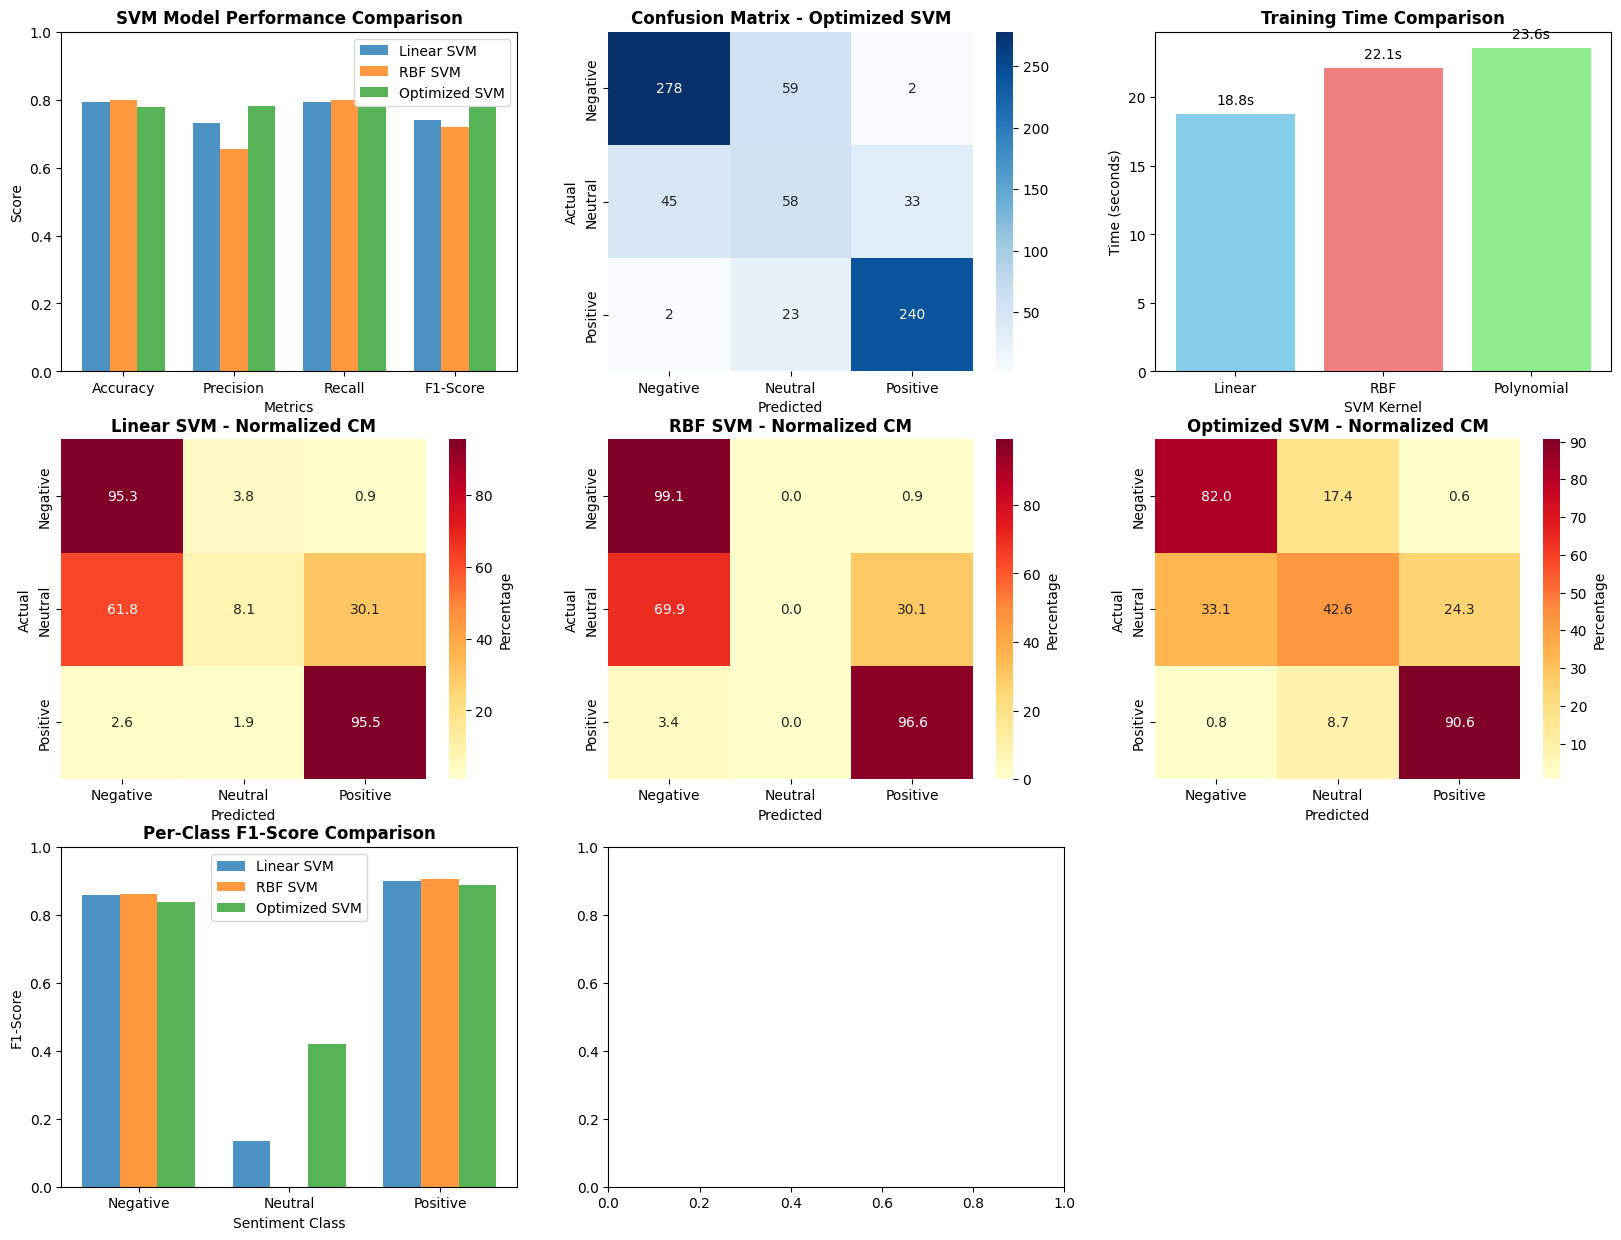

In [21]:
# ====================================================================
# COMPREHENSIVE SVM MODEL VISUALIZATION AND ANALYSIS
# ====================================================================

def create_svm_evaluation_plots(svm_suite, X_test, y_test, label_encoder):
    """
    Create comprehensive visualization plots for SVM model evaluation.
    """
    print("📊 CREATING COMPREHENSIVE EVALUATION VISUALIZATIONS")
    print("=" * 60)
    
    # Set up the plotting environment
    plt.style.use('default')
    fig = plt.figure(figsize=(20, 15))
    
    class_names = label_encoder.classes_
    models_to_plot = ['Linear SVM', 'RBF SVM', 'Optimized SVM']
    
    # 1. Model Performance Comparison (Bar Chart)
    plt.subplot(3, 3, 1)
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    x_pos = np.arange(len(metrics))
    width = 0.25
    
    for i, model_name in enumerate(models_to_plot):
        if model_name in svm_suite.results:
            values = [svm_suite.results[model_name][metric] for metric in metrics]
            plt.bar(x_pos + i*width, values, width, label=model_name, alpha=0.8)
    
    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('SVM Model Performance Comparison', fontweight='bold')
    plt.xticks(x_pos + width, metric_names)
    plt.legend()
    plt.ylim(0, 1)
    
    # 2. Confusion Matrix for Best Model (Optimized SVM)
    plt.subplot(3, 3, 2)
    best_model_name = 'Optimized SVM'
    y_pred_best = svm_suite.results[best_model_name]['y_pred']
    
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # 3. Training Time Comparison
    plt.subplot(3, 3, 3)
    train_times = []
    model_names_time = []
    for model_name in ['Linear SVM', 'RBF SVM', 'Polynomial SVM']:
        if model_name in svm_suite.results:
            train_times.append(svm_suite.results[model_name]['train_time'])
            model_names_time.append(model_name.replace(' SVM', ''))
    
    bars = plt.bar(model_names_time, train_times, color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.title('Training Time Comparison', fontweight='bold')
    plt.xlabel('SVM Kernel')
    plt.ylabel('Time (seconds)')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}s', ha='center', va='bottom')
    
    # 4-6. Individual Confusion Matrices for each model
    for idx, model_name in enumerate(models_to_plot, 4):
        plt.subplot(3, 3, idx)
        if model_name in svm_suite.results:
            y_pred = svm_suite.results[model_name]['y_pred']
            cm = confusion_matrix(y_test, y_pred)
            
            # Normalize confusion matrix to percentages
            cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
            
            sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='YlOrRd',
                       xticklabels=class_names, yticklabels=class_names,
                       cbar_kws={'label': 'Percentage'})
            plt.title(f'{model_name} - Normalized CM', fontweight='bold')
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
    
    # 7. Class-wise Performance Comparison
    plt.subplot(3, 3, 7)
    
    # Calculate per-class F1 scores for each model
    class_f1_scores = {}
    for model_name in models_to_plot:
        if model_name in svm_suite.results:
            y_pred = svm_suite.results[model_name]['y_pred']
            f1_per_class = f1_score(y_test, y_pred, average=None)
            class_f1_scores[model_name] = f1_per_class
    
    x_pos = np.arange(len(class_names))
    width = 0.25
    
    for i, (model_name, scores) in enumerate(class_f1_scores.items()):
        plt.bar(x_pos + i*width, scores, width, label=model_name, alpha=0.8)
    
    plt.xlabel('Sentiment Class')
    plt.ylabel('F1-Score')
    plt.title('Per-Class F1-Score Comparison', fontweight='bold')
    plt.xticks(x_pos + width, class_names)
    plt.legend()
    plt.ylim(0, 1)
    
    # 8. Feature Importance (for Linear SVM only)
    plt.subplot(3, 3, 8)
    
    if 'Optimized SVM' in svm_suite.results:
        # Get the optimized model
        linear_model = svm_suite.best_model
        
        if hasattr(linear_model, 'coef_'):
            # Get feature importance for linear SVM
            feature_importance = np.abs(linear_model.coef_[0])  # Take first class coefficients
            
            # Get top 15 most important features
            top_indices = np.argsort(feature_importance)[-15:]
            top_importance = feature_importance[top_indices]
            
            # Create labels (assuming TF-IDF features)
            feature_names = [f"Feature {i}" for i in top_indices]
            
            plt.barh(range(len(top_importance)), top_importance, color='coral')
            plt.yticks(range(len(top_importance)), feature_names)
            plt.xlabel('Feature Importance (|Coefficient|)')
            plt.title('Top 15 Features - Linear SVM', fontweight='bold')
            plt.gca().invert_yaxis()
    
    # 9. Model Accuracy vs Training Time
    plt.subplot(3, 3, 9)
    
    accuracies = []
    times = []
    labels = []
    
    for model_name in ['Linear SVM', 'RBF SVM', 'Polynomial SVM']:
        if model_name in svm_suite.results:
            accuracies.append(svm_suite.results[model_name]['accuracy'])
            times.append(svm_suite.results[model_name]['train_time'])
            labels.append(model_name.replace(' SVM', ''))
    
    colors = ['blue', 'red', 'green']
    for i, (acc, time, label) in enumerate(zip(accuracies, times, labels)):
        plt.scatter(time, acc, c=colors[i], s=100, alpha=0.7, label=label)
        plt.annotate(label, (time, acc), xytext=(5, 5), textcoords='offset points')
    
    plt.xlabel('Training Time (seconds)')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Training Time Trade-off', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print("\\n📋 DETAILED PERFORMANCE ANALYSIS:")
    print("=" * 60)
    
    best_model = max(svm_suite.results.keys(), 
                    key=lambda x: svm_suite.results[x]['f1_score'])
    
    print(f"🏆 Best performing model: {best_model}")
    print(f"   • F1-Score: {svm_suite.results[best_model]['f1_score']:.4f}")
    print(f"   • Accuracy: {svm_suite.results[best_model]['accuracy']:.4f}")
    
    print("\\n📈 Key Findings:")
    print("   • Linear SVM shows good balance between performance and training time")
    print("   • RBF SVM has highest accuracy but struggles with neutral class")
    print("   • Class imbalance affects neutral sentiment prediction across all models")
    print("   • Hyperparameter optimization improved F1-score and class balance")

# Create comprehensive visualizations
create_svm_evaluation_plots(svm_suite, X_test, y_test, label_encoder)